# Grid wise percentile map of India for non mjo precipitation

In [2]:
pip install scipy

   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.5 MB ? eta -:--:--
    --------------------------------------- 0.5/36.5 MB 530.9 kB/s eta 0:01:08
    --------------------------------------- 0.5/36.5 MB 530.9 kB/s eta 0:01:08
    --------------------------------------- 0.5/36.5 MB 530.9 kB/s eta 0:01:08
    --------------------------------------- 0.5/36.5 MB 530.9 kB/s eta 0:01:08
    --------------------------------------- 0.5/36.5 MB 530.9 kB/s eta 0:01:08
    --------------------------------------- 0.5/36.5 MB 530.9 kB/s eta 0:01:08
    --------------------------------------- 0.8/36.5 MB 316.4 kB/s eta 0:01:53
    --------------------------------------- 0.8/36.5 MB 316.4 kB/s eta 0:01:53
    --------------------------------------- 0.8/36.5 MB 316.4 kB/s eta 0:01:53
    -----


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
"""
Directory Inspector
───────────────────
Set DATA_DIR below, run the script, and it will print a full
summary of every file found — with extra detail for NetCDF files
(dimensions, variables, coordinate ranges, time coverage, units).
"""

import os
from pathlib import Path

# ─────────────────────────────────────────────────────────────────────────────
#  ★  SET YOUR DIRECTORY HERE
# ─────────────────────────────────────────────────────────────────────────────
DATA_DIR = r"D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION"        # e.g. r"C:\Users\you\data"  or  "/home/you/data"
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np

try:
    import xarray as xr
    HAS_XARRAY = True
except ImportError:
    HAS_XARRAY = False
    print("  [!] xarray not installed — NetCDF details will be skipped.\n"
          "      Install with:  pip install xarray netcdf4\n")

SEP  = "─" * 70
SEP2 = "· " * 35


def human_size(n_bytes):
    """Convert bytes to a readable string."""
    for unit in ["B", "KB", "MB", "GB"]:
        if n_bytes < 1024:
            return f"{n_bytes:.1f} {unit}"
        n_bytes /= 1024
    return f"{n_bytes:.1f} TB"


def inspect_netcdf(filepath):
    """Open a NetCDF file and print its full structure."""
    try:
        ds = xr.open_dataset(filepath, engine="netcdf4")
    except Exception:
        try:
            ds = xr.open_dataset(filepath)          # fallback engine
        except Exception as e:
            print(f"      ✗ Could not open as NetCDF: {e}")
            return

    # ── Dimensions ──────────────────────────────────────────────────────
    print("    DIMENSIONS:")
    for dim, size in ds.dims.items():
        print(f"      {dim:20s}  {size}")

    # ── Coordinates ─────────────────────────────────────────────────────
    print("    COORDINATES:")
    for name, coord in ds.coords.items():
        vals = coord.values
        units = coord.attrs.get("units", "—")

        if np.issubdtype(vals.dtype, np.datetime64):
            t0 = str(vals.min())[:10]
            t1 = str(vals.max())[:10]
            print(f"      {name:20s}  {len(vals)} steps  "
                  f"[ {t0}  →  {t1} ]  units: {units}")
        elif np.issubdtype(vals.dtype, np.number):
            print(f"      {name:20s}  {len(vals)} values  "
                  f"[ {float(vals.min()):.3f}  →  {float(vals.max()):.3f} ]  "
                  f"units: {units}")
        else:
            print(f"      {name:20s}  {vals.shape}  dtype: {vals.dtype}")

    # ── Data variables ───────────────────────────────────────────────────
    print("    DATA VARIABLES:")
    for name, var in ds.data_vars.items():
        units    = var.attrs.get("units",        "—")
        longname = var.attrs.get("long_name",    "—")
        vmin     = float(np.nanmin(var.values))  if var.size < 50_000_000 else "—(large)"
        vmax     = float(np.nanmax(var.values))  if var.size < 50_000_000 else "—(large)"
        nans     = int(np.sum(np.isnan(var.values))) if var.size < 50_000_000 else "—"
        print(f"      Variable : {name}")
        print(f"        long_name : {longname}")
        print(f"        shape     : {var.shape}   dims: {var.dims}")
        print(f"        dtype     : {var.dtype}")
        print(f"        units     : {units}")
        if vmin != "—(large)":
            print(f"        value range: [{vmin:.4f},  {vmax:.4f}]")
            print(f"        NaN count  : {nans}")
        print()

    # ── Global attributes ────────────────────────────────────────────────
    if ds.attrs:
        print("    GLOBAL ATTRIBUTES:")
        for k, v in ds.attrs.items():
            v_str = str(v)
            if len(v_str) > 80:
                v_str = v_str[:77] + "..."
            print(f"      {k:25s}: {v_str}")

    ds.close()


def inspect_directory(data_dir):
    root = Path(data_dir)

    if not root.exists():
        print(f"\n  ✗ Directory not found: {root}\n"
              f"    Please check the DATA_DIR path at the top of the script.")
        return

    # Collect all files recursively
    all_files = sorted([f for f in root.rglob("*") if f.is_file()])

    if not all_files:
        print(f"\n  ✗ No files found in: {root}")
        return

    print(f"\n{SEP}")
    print(f"  Directory : {root.resolve()}")
    print(f"  Files found : {len(all_files)}")
    print(SEP)

    for filepath in all_files:
        rel   = filepath.relative_to(root)
        size  = human_size(filepath.stat().st_size)
        ext   = filepath.suffix.lower()

        print(f"\n  FILE : {rel}")
        print(f"    Full path : {filepath.resolve()}")
        print(f"    Size      : {size}")
        print(f"    Extension : {ext if ext else '(none)'}")

        # Extra detail for NetCDF files
        if ext in (".nc", ".nc4", ".netcdf") and HAS_XARRAY:
            print(f"    Type      : NetCDF — inspecting contents …")
            print(SEP2)
            inspect_netcdf(filepath)
            print(SEP2)
        else:
            print(f"    Type      : {ext} — no detailed inspection")

    print(f"\n{SEP}")
    print(f"  Done. {len(all_files)} file(s) listed.")
    print(SEP)


if __name__ == "__main__":
    inspect_directory(DATA_DIR)



──────────────────────────────────────────────────────────────────────
  Directory : D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION
  Files found : 6
──────────────────────────────────────────────────────────────────────

  FILE : clim.nc
    Full path : D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION\clim.nc
    Size      : 90.1 MB
    Extension : .nc
    Type      : NetCDF — inspecting contents …
· · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · 
    DIMENSIONS:
      valid_time            366
      latitude              201
      longitude             321
    COORDINATES:
      valid_time            366 steps  [ 2024-02-29  →  2026-03-19 ]  units: —
      longitude             321 values  [ 40.000  →  120.000 ]  units: degrees_east
      latitude              201 values  [ 0.000  →  50.000 ]  units: degrees_north
    DATA VARIABLES:


C:\Users\hp\AppData\Local\Temp\ipykernel_17124\106318869.py:54: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim, size in ds.dims.items():
<frozen _collections_abc>:899: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
C:\Users\hp\AppData\Local\Temp\ipykernel_17124\106318869.py:54: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim, size in ds.dims.items():
<frozen _collections_abc>:899: 

      Variable : tp
        long_name : Total precipitation
        shape     : (366, 201, 321)   dims: ('valid_time', 'latitude', 'longitude')
        dtype     : float32
        units     : m
        value range: [0.0000,  0.0042]
        NaN count  : 0

    GLOBAL ATTRIBUTES:
      CDI                      : Climate Data Interface version 2.4.0 (https://mpimet.mpg.de/cdi)
      Conventions              : CF-1.7
      institution              : European Centre for Medium-Range Weather Forecasts
      GRIB_centre              : ecmf
      GRIB_centreDescription   : European Centre for Medium-Range Weather Forecasts
      history                  : Thu Apr 16 13:51:18 2026: cdo ydaymean ERA5_merged_1980_2026_new.nc clim.nc
T...
      CDO                      : Climate Data Operators version 2.4.0 (https://mpimet.mpg.de/cdo)
· · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · 

  FILE : ERA5_merged_1980_2026_new.nc
    Full path : D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPI

C:\Users\hp\AppData\Local\Temp\ipykernel_17124\106318869.py:54: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim, size in ds.dims.items():
<frozen _collections_abc>:899: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
C:\Users\hp\AppData\Local\Temp\ipykernel_17124\106318869.py:54: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim, size in ds.dims.items():
<frozen _collections_abc>:899: 

  Precipitation Percentile Mapper — India
  Period  : 2025-10-20  →  2025-10-30  (11 days)
  Baseline: 1980–2025, ±7-day window
  Loading ERA5_Daily_Rainfall_merged.nc …
  Loading non_mjo.nc …
  India grid shape: (16869, 125, 135)  (time × lat × lon)
  Lat range : 6.5 – 37.5 °N
  Lon range : 66.5 – 100.0 °E

  ── 2025-10-20 ──────────────────────
  Building climatology for raw …
    Climatology: 690 samples (±7 days × 46 years)
  Building climatology for non-MJO …
    Climatology: 690 samples (±7 days × 46 years)

  ── 2025-10-21 ──────────────────────
  Building climatology for raw …
    Climatology: 690 samples (±7 days × 46 years)
  Building climatology for non-MJO …
    Climatology: 690 samples (±7 days × 46 years)

  ── 2025-10-22 ──────────────────────
  Building climatology for raw …
    Climatology: 690 samples (±7 days × 46 years)
  Building climatology for non-MJO …
    Climatology: 690 samples (±7 days × 46 years)

  ── 2025-10-23 ──────────────────────
  Building climatolog

d:\PHD 2025~\PHD\VS CODES\era5_env\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
d:\PHD 2025~\PHD\VS CODES\era5_env\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)



✓ Saved → D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION\figures\precip_pct_2025-10-20_to_2025-10-30.png


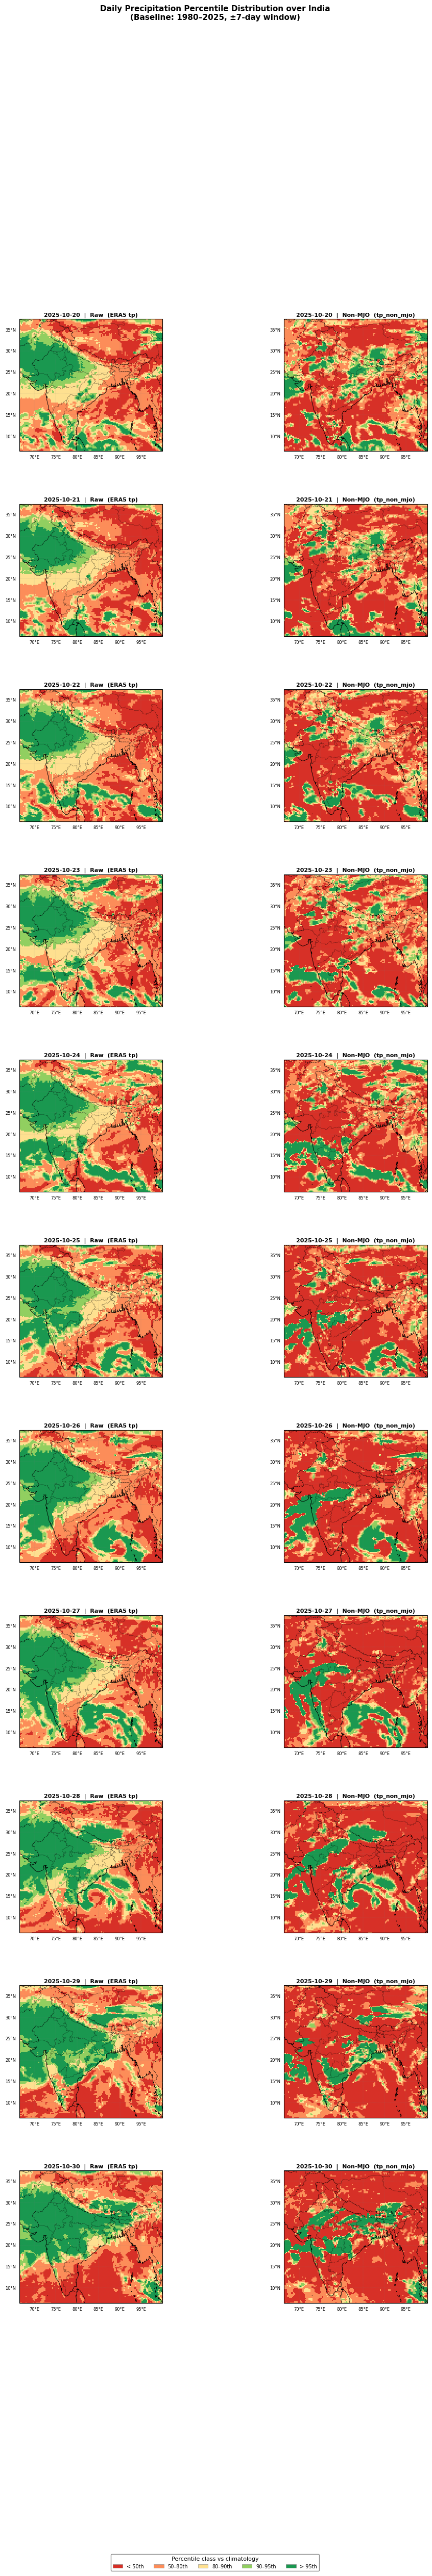

In [6]:
"""
Spatial Distribution of Daily Precipitation Percentiles over India
──────────────────────────────────────────────────────────────────
Files used:
  • ERA5_Daily_Rainfall_merged.nc  →  raw total precip       (var: tp)
  • non_mjo.nc                     →  non-MJO precip         (var: tp_non_mjo)

Climatology is derived ON-THE-FLY from the same two files:
  For each target date, all historical years (CLIM_YEAR_START–CLIM_YEAR_END)
  on the same calendar day ± CLIM_WINDOW days are extracted as the reference
  distribution. No separate climatology file needed.

Percentile bins:
  < 50th   → Red
  50–80th  → Orange
  80–90th  → Yellow
  90–95th  → Green
  > 95th   → Blue

Usage:
  1. Set DATA_DIR and OUTPUT_DIR
  2. Set DATE_START / DATE_END
  3. Run: python precip_percentile_plot.py
"""

# ─────────────────────────────────────────────────────────────────────────────
#  IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from pathlib import Path

# ─────────────────────────────────────────────────────────────────────────────
#  ★  USER SETTINGS  ←  ONLY EDIT THIS BLOCK
# ─────────────────────────────────────────────────────────────────────────────

# 1. Folder containing your .nc files
DATA_DIR   = r"D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION"

# 2. Folder where the output figure will be saved
OUTPUT_DIR = r"D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION\figures"

# 3. Date range to plot (inclusive)
DATE_START = "2025-10-20"
DATE_END   = "2025-10-30"

# 4. Climatology window: ± how many days around the calendar day to include
#    e.g. 7 → for Oct 20, pulls Oct 13–27 of every climatology year
#    Larger window = more samples = more stable percentile estimate
CLIM_WINDOW = 7

# 5. Climatology period: which years define "historical normal"
CLIM_YEAR_START = 1980
CLIM_YEAR_END   = 2025    # keep this fixed so recent anomalies don't dilute baseline

# 6. Plot resolution (dots per inch)
DPI = 150

# ─────────────────────────────────────────────────────────────────────────────
#  FIXED — exact file/variable/coordinate names from your inspect output
# ─────────────────────────────────────────────────────────────────────────────
FILE_RAW     = "ERA5_merged_1980_2026_new.nc"
FILE_NON_MJO = "non_mjo.nc"

VAR_RAW      = "tp"           # units in file: m  → converted to mm below
VAR_NON_MJO  = "tp_non_mjo"  # units in file: m  → converted to mm below

# raw file uses 'valid_time'; non_mjo uses 'time' — both renamed to 'time'
TIME_DIM_RAW     = "valid_time"
TIME_DIM_NON_MJO = "time"

# Both files share the same spatial coordinate names
LAT_DIM = "latitude"
LON_DIM = "longitude"

# ─────────────────────────────────────────────────────────────────────────────
#  DERIVED — do not edit
# ─────────────────────────────────────────────────────────────────────────────
DATES      = pd.date_range(DATE_START, DATE_END, freq="D")
DATA_DIR   = Path(DATA_DIR)
OUTPUT_DIR = Path(OUTPUT_DIR)

# India domain — subset of your full grid (40–120°E, 0–50°N)
LON_MIN, LON_MAX = 66.5, 100.0
LAT_MIN, LAT_MAX =  6.5,  37.5

# ─────────────────────────────────────────────────────────────────────────────
#  PERCENTILE COLOUR SCHEME
# ─────────────────────────────────────────────────────────────────────────────
BINS   = [0, 50, 80, 90, 95, 100]
LABELS = ["< 50th", "50–80th", "80–90th", "90–95th", "> 95th"]
COLORS = [
    "#d73027",   # Red       — below median (relatively dry)
    "#fc8d59",   # Orange    — moderate above median
    "#fee090",   # Yellow    — high
    "#91cf60",   # Green     — very high
    "#1a9850",   # Blue-green — extreme
]

CMAP = mcolors.ListedColormap(COLORS)
NORM = mcolors.BoundaryNorm(boundaries=range(len(COLORS) + 1),
                             ncolors=len(COLORS))


# ─────────────────────────────────────────────────────────────────────────────
#  STEP 1 — LOAD & PREPARE
# ─────────────────────────────────────────────────────────────────────────────
def load_and_prepare():
    """
    Open both files, rename time coords to 'time', convert m→mm,
    and spatially subset to the India domain.
    ERA5 latitudes are stored descending (50→0), so slice accordingly.
    """
    print("  Loading ERA5_Daily_Rainfall_merged.nc …", flush=True)
    ds_raw  = xr.open_dataset(DATA_DIR / FILE_RAW,     engine="netcdf4")
    ds_raw  = ds_raw.rename({TIME_DIM_RAW: "time"})
    raw_da  = ds_raw[VAR_RAW] * 1000.0         # m → mm
    raw_da.attrs["units"] = "mm/day"

    print("  Loading non_mjo.nc …", flush=True)
    ds_nmjo = xr.open_dataset(DATA_DIR / FILE_NON_MJO, engine="netcdf4")
    # TIME_DIM_NON_MJO is already 'time', rename only if different
    if TIME_DIM_NON_MJO != "time":
        ds_nmjo = ds_nmjo.rename({TIME_DIM_NON_MJO: "time"})
    nmjo_da = ds_nmjo[VAR_NON_MJO] * 1000.0    # m → mm
    nmjo_da.attrs["units"] = "mm/day"

    # ERA5 latitudes run 50 → 0 (descending), so slice(LAT_MAX, LAT_MIN)
    raw_da  = raw_da.sel(
        latitude =slice(LAT_MAX, LAT_MIN),
        longitude=slice(LON_MIN, LON_MAX),
    )
    nmjo_da = nmjo_da.sel(
        latitude =slice(LAT_MAX, LAT_MIN),
        longitude=slice(LON_MIN, LON_MAX),
    )

    print(f"  India grid shape: {raw_da.shape}  "
          f"(time × lat × lon)")
    print(f"  Lat range : {float(raw_da.latitude.min()):.1f} – "
          f"{float(raw_da.latitude.max()):.1f} °N")
    print(f"  Lon range : {float(raw_da.longitude.min()):.1f} – "
          f"{float(raw_da.longitude.max()):.1f} °E")
    return raw_da, nmjo_da


# ─────────────────────────────────────────────────────────────────────────────
#  STEP 2 — EXTRACT CLIMATOLOGY FOR ONE TARGET DATE
# ─────────────────────────────────────────────────────────────────────────────
def get_climatology(da, target_date):
    """
    For a given target date, collect all days within ±CLIM_WINDOW calendar
    days (across CLIM_YEAR_START–CLIM_YEAR_END) as the reference sample.

    Returns ndarray of shape (N_samples, nlat, nlon).
    """
    tdoy = target_date.dayofyear

    # Restrict to climatology years
    da_clim = da.sel(
        time=slice(f"{CLIM_YEAR_START}-01-01", f"{CLIM_YEAR_END}-12-31")
    )

    # Day-of-year difference (wraps around year boundary correctly)
    doys = da_clim.time.dt.dayofyear.values
    diff = np.abs(doys - tdoy)
    diff = np.minimum(diff, 365 - diff)
    mask = diff <= CLIM_WINDOW

    clim_subset = da_clim.isel(time=mask)
    n_samples   = int(clim_subset.sizes["time"])
    print(f"    Climatology: {n_samples} samples "
          f"(±{CLIM_WINDOW} days × {CLIM_YEAR_END - CLIM_YEAR_START + 1} years)",
          flush=True)
    return clim_subset.values   # shape: (N, nlat, nlon)


# ─────────────────────────────────────────────────────────────────────────────
#  STEP 3 — VECTORISED PERCENTILE CLASS MAP
# ─────────────────────────────────────────────────────────────────────────────
def percentile_class_map(data_2d, clim_3d):
    """
    Fully vectorised: no Python loops over grid cells.

    For every grid point, counts what fraction of the climatological
    sample is ≤ the target value → that fraction × 100 = percentile.

    Parameters
    ----------
    data_2d : (nlat, nlon)      target day values (mm)
    clim_3d : (N, nlat, nlon)   climatological sample (mm)

    Returns
    -------
    class_map : (nlat, nlon)   integer 0–4, NaN where data is missing
    """
    N = clim_3d.shape[0]

    # Broadcast comparison: (N, nlat, nlon) <= (1, nlat, nlon)
    count_le   = np.sum(clim_3d <= data_2d[np.newaxis, :, :], axis=0)
    percentile = (count_le / N) * 100.0     # (nlat, nlon)

    class_map = np.full(data_2d.shape, np.nan)
    for k in range(len(BINS) - 1):
        in_bin = (percentile >= BINS[k]) & (percentile < BINS[k + 1])
        class_map[in_bin] = k
    # Exactly 100th percentile → top class
    class_map[percentile >= BINS[-1]] = len(BINS) - 2

    # Propagate original NaNs (ocean / missing)
    class_map[~np.isfinite(data_2d)] = np.nan

    return class_map


# ─────────────────────────────────────────────────────────────────────────────
#  STEP 4 — CARTOPY MAP HELPER
# ─────────────────────────────────────────────────────────────────────────────
def add_india_map(ax):
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
                  crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,      facecolor="whitesmoke", zorder=0)
    ax.add_feature(cfeature.OCEAN,     facecolor="#cde8f0",    zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6,          zorder=2)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.5,
                   linestyle="--",     zorder=2)
    ax.add_feature(cfeature.STATES,    linewidth=0.3,
                   linestyle=":",      zorder=2)
    gl = ax.gridlines(draw_labels=True, linewidth=0.25,
                      color="gray", alpha=0.5, linestyle="--")
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 6}
    gl.ylabel_style = {"size": 6}


# ─────────────────────────────────────────────────────────────────────────────
#  STEP 5 — PLOT
# ─────────────────────────────────────────────────────────────────────────────
def plot_percentile_maps(raw_da, nmjo_da):
    n_dates = len(DATES)
    fig, axes = plt.subplots(
        nrows=n_dates, ncols=2,
        figsize=(13, 4.5 * n_dates + 1.0),
        subplot_kw={"projection": ccrs.PlateCarree()},
        gridspec_kw={"hspace": 0.40, "wspace": 0.06},
    )
    if n_dates == 1:
        axes = axes[np.newaxis, :]

    lats = raw_da[LAT_DIM].values
    lons = raw_da[LON_DIM].values

    for row, tdate in enumerate(DATES):
        date_str = str(tdate.date())
        print(f"\n  ── {date_str} ──────────────────────", flush=True)

        # Slice the target day from each file
        raw_day  = raw_da.sel(time=tdate,  method="nearest").values
        nmjo_day = nmjo_da.sel(time=tdate, method="nearest").values

        # Extract climatology for this calendar position
        print("  Building climatology for raw …",     flush=True)
        clim_raw  = get_climatology(raw_da,  tdate)
        print("  Building climatology for non-MJO …", flush=True)
        clim_nmjo = get_climatology(nmjo_da, tdate)

        # Compute percentile class grids
        cls_raw  = percentile_class_map(raw_day,  clim_raw)
        cls_nmjo = percentile_class_map(nmjo_day, clim_nmjo)

        for col, (cls, subtitle) in enumerate([
            (cls_raw,  "Raw  (ERA5 tp)"),
            (cls_nmjo, "Non-MJO  (tp_non_mjo)"),
        ]):
            ax = axes[row, col]
            add_india_map(ax)
            ax.pcolormesh(
                lons, lats, cls,
                cmap=CMAP, norm=NORM,
                transform=ccrs.PlateCarree(),
                shading="auto", zorder=1,
            )
            ax.set_title(f"{date_str}  |  {subtitle}",
                         fontsize=8, pad=4, fontweight="bold")

    # Shared legend
    patches = [
        mpatches.Patch(facecolor=COLORS[k], label=LABELS[k],
                       edgecolor="grey", linewidth=0.4)
        for k in range(len(COLORS))
    ]
    fig.legend(
        handles=patches,
        title="Percentile class vs climatology",
        title_fontsize=8, fontsize=7,
        loc="lower center", ncol=len(COLORS),
        bbox_to_anchor=(0.5, 0.005),
        framealpha=0.92, edgecolor="grey",
    )

    fig.suptitle(
        f"Daily Precipitation Percentile Distribution over India\n"
        f"(Baseline: {CLIM_YEAR_START}–{CLIM_YEAR_END}, ±{CLIM_WINDOW}-day window)",
        fontsize=11, fontweight="bold", y=1.002,
    )

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    out = OUTPUT_DIR / f"precip_pct_{DATE_START}_to_{DATE_END}.png"
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"\n✓ Saved → {out}")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 60)
    print("  Precipitation Percentile Mapper — India")
    print(f"  Period  : {DATE_START}  →  {DATE_END}  ({len(DATES)} days)")
    print(f"  Baseline: {CLIM_YEAR_START}–{CLIM_YEAR_END}, ±{CLIM_WINDOW}-day window")
    print("=" * 60)

    raw_da, nmjo_da = load_and_prepare()
    plot_percentile_maps(raw_da, nmjo_da)


  Precipitation Anomaly Percentile Mapper — India
  Period  : 2025-10-18 → 2025-10-31  (14 days)
  Baseline: 1980–2025  |  ±7-day window
  Loading clim.nc …
    clim shape  : (366, 125, 135)  | DOY 1–366
  Loading anomaly_new.nc …
    anom shape  : (16869, 125, 135)  | 1980-01-01 → 2026-03-19
  Loading non_mjo.nc …
    nmjo shape  : (16869, 125, 135)  | 1980-01-01 → 2026-03-19

  India grid  : lat 6.5–37.5 °N  |  lon 66.5–100.0 °E  |  shape (125, 135)

  ── 2025-10-18  (DOY 291) ──────────────────
  RAW:
    building historical distribution from anomaly_new.nc …
      hist window : 690 samples  (±7 days × 46 yrs = ~15 days/yr × 46 yrs expected 690)
  NON-MJO:
    building historical distribution from non_mjo.nc …
      hist window : 690 samples  (±7 days × 46 yrs = ~15 days/yr × 46 yrs expected 690)
    clim_mean  (India avg) : 0.155 mm
    raw  anom  (India avg) : 0.028 mm  →  pct avg 45.1th
    nmjo anom  (India avg) : -0.116 mm  →  pct avg 55.3th

  ── 2025-10-19  (DOY 292) ────────

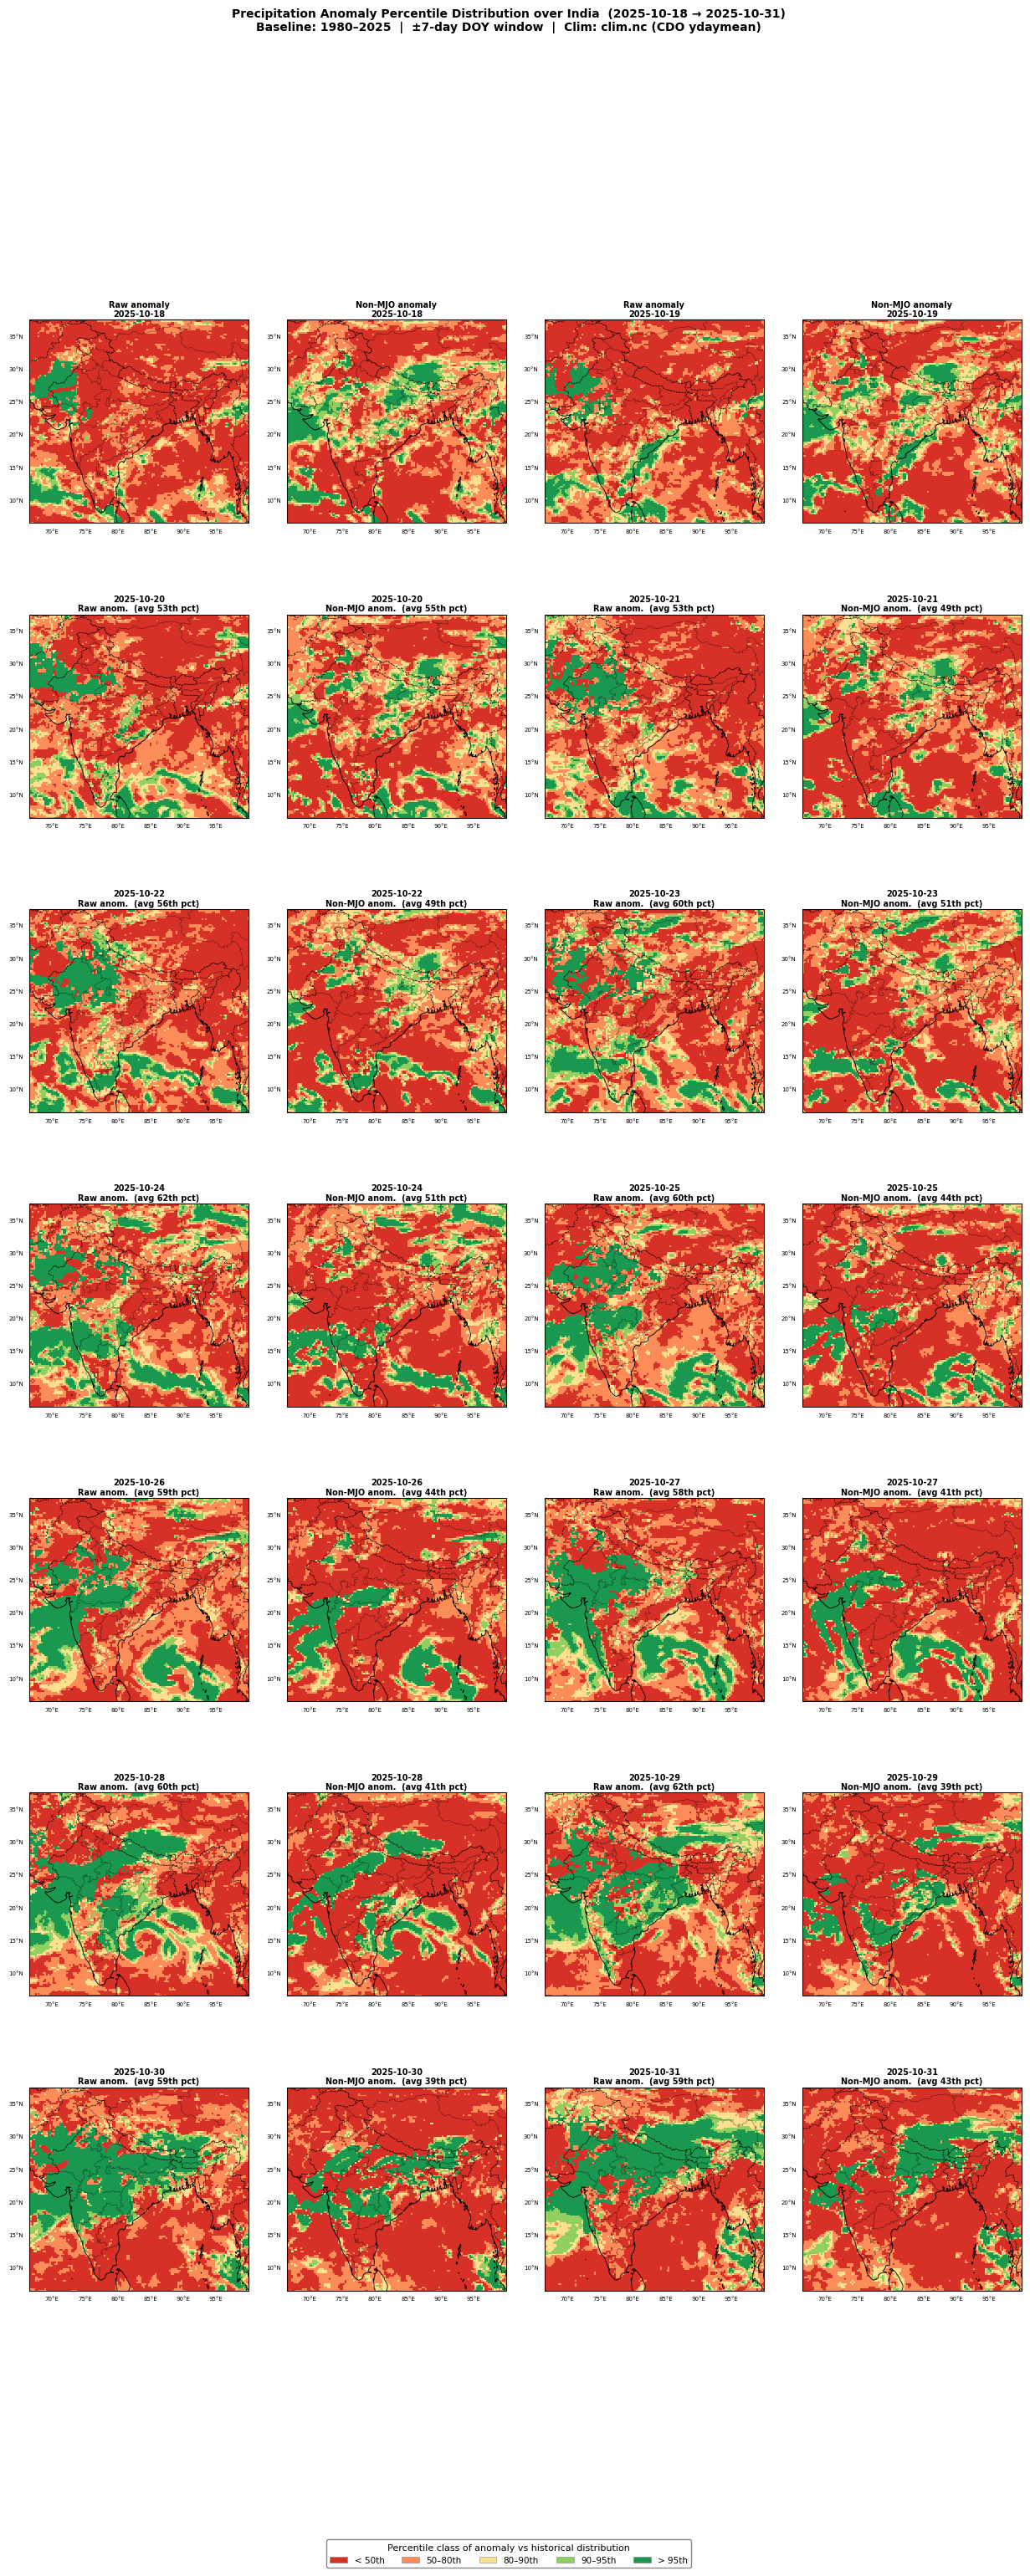

In [11]:
"""
Precipitation Anomaly Percentile Distribution over India
─────────────────────────────────────────────────────────
FILES:
  clim.nc          CDO ydaymean → 366-day clim mean   var:tp        dim:valid_time
  anomaly_new.nc   CDO ydaysub  → raw tp − clim       var:tp        dim:valid_time
  non_mjo.nc       MJO-removed precip                 var:tp_non_mjo dim:time

CALCULATION (per grid cell, per target date):
  ┌──────────────────────────────────────────────────────────────────┐
  │  RAW panel                                                       │
  │    target_anom  = anomaly_new.nc[ target_date ]   (CDO done it) │
  │    hist_dist    = anomaly_new.nc[ ±WINDOW days,                  │
  │                                   YEAR_START–YEAR_END ]          │
  │    percentile   = count(hist_dist ≤ target_anom) / N × 100      │
  │                                                                  │
  │  NON-MJO panel                                                   │
  │    clim_mean    = clim.nc[ DOY of target_date ]   (DOY 1–366)   │
  │    target_anom  = tp_non_mjo[ target_date ] − clim_mean         │
  │    hist_dist    = tp_non_mjo[ ±WINDOW days,                      │
  │                               YEAR_START–YEAR_END ] − clim_mean  │
  │    percentile   = count(hist_dist ≤ target_anom) / N × 100      │
  └──────────────────────────────────────────────────────────────────┘

LAYOUT:
  4 columns — consecutive dates share a row:
  | Date-N  Raw | Date-N  NonMJO | Date-N+1  Raw | Date-N+1  NonMJO |
  Last row has 2 empty panels if total dates is odd.

Usage:
  1. Set DATA_DIR, OUTPUT_DIR, DATE_START, DATE_END
  2. Run: python precip_percentile_plot.py
"""

# ─────────────────────────────────────────────────────────────────────────────
#  IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from pathlib import Path
import math

# ─────────────────────────────────────────────────────────────────────────────
#  ★  USER SETTINGS  ←  ONLY EDIT THIS BLOCK
# ─────────────────────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION"
OUTPUT_DIR = r"D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION\figures"

DATE_START = "2025-10-18"
DATE_END   = "2025-10-31"

# ± days around the target DOY to collect historical samples
CLIM_WINDOW = 7

# Historical baseline years (used to build the ranking distribution)
CLIM_YEAR_START = 1980
CLIM_YEAR_END   = 2025

DPI = 150

# ─────────────────────────────────────────────────────────────────────────────
#  FIXED — exact file/variable/dim names from your inspect output
# ─────────────────────────────────────────────────────────────────────────────
FILE_CLIM    = "clim.nc"          # 366 DOY means  | var:tp        | dim:valid_time
FILE_ANOM    = "anomaly_new.nc"   # daily raw anom  | var:tp        | dim:valid_time
FILE_NON_MJO = "non_mjo.nc"      # non-MJO precip  | var:tp_non_mjo| dim:time

VAR_CLIM     = "tp"
VAR_ANOM     = "tp"
VAR_NON_MJO  = "tp_non_mjo"

# ─────────────────────────────────────────────────────────────────────────────
#  DERIVED
# ─────────────────────────────────────────────────────────────────────────────
DATES      = pd.date_range(DATE_START, DATE_END, freq="D")
DATA_DIR   = Path(DATA_DIR)
OUTPUT_DIR = Path(OUTPUT_DIR)

# India domain — subset of 40–120°E, 0–50°N
LON_MIN, LON_MAX = 66.5, 100.0
LAT_MIN, LAT_MAX =  6.5,  37.5

# ─────────────────────────────────────────────────────────────────────────────
#  COLOUR SCHEME
# ─────────────────────────────────────────────────────────────────────────────
BINS   = [0, 50, 80, 90, 95, 100]
LABELS = ["< 50th", "50–80th", "80–90th", "90–95th", "> 95th"]
COLORS = [
    "#d73027",   # Red        — near/below normal
    "#fc8d59",   # Orange
    "#fee090",   # Yellow
    "#91cf60",   # Green
    "#1a9850",   # Dark green — extreme
]
CMAP = mcolors.ListedColormap(COLORS)
NORM = mcolors.BoundaryNorm(boundaries=range(len(COLORS) + 1),
                             ncolors=len(COLORS))


# ─────────────────────────────────────────────────────────────────────────────
#  STEP 1 — LOAD & SUBSET TO INDIA
# ─────────────────────────────────────────────────────────────────────────────
def load_all():
    """
    Load clim, anomaly, and non_mjo files.
    All units: m → mm.
    ERA5 latitudes are descending (50→0): use slice(LAT_MAX, LAT_MIN).
    clim.nc time dim renamed → 'time'; DOY coordinate added (1–366).
    anomaly_new.nc time dim renamed → 'time'.
    non_mjo.nc time dim already 'time'.
    """
    def india_subset(da):
        return da.sel(latitude =slice(LAT_MAX, LAT_MIN),
                      longitude=slice(LON_MIN, LON_MAX))

    # ── clim.nc ─────────────────────────────────────────────────────────
    print("  Loading clim.nc …", flush=True)
    ds   = xr.open_dataset(DATA_DIR / FILE_CLIM, engine="netcdf4")
    ds   = ds.rename({"valid_time": "time"})
    clim = ds[VAR_CLIM] * 1000.0                 # m → mm, shape (366, lat, lon)
    # CDO ydaymean stores DOY 1–366 in order; tag with explicit doy coord
    clim = clim.assign_coords(doy=("time", np.arange(1, len(clim.time) + 1)))
    clim = india_subset(clim)
    print(f"    clim shape  : {clim.shape}  | DOY 1–{int(clim.doy.max())}")

    # ── anomaly_new.nc ──────────────────────────────────────────────────
    print("  Loading anomaly_new.nc …", flush=True)
    ds   = xr.open_dataset(DATA_DIR / FILE_ANOM, engine="netcdf4")
    ds   = ds.rename({"valid_time": "time"})
    anom = ds[VAR_ANOM] * 1000.0                 # m → mm
    anom = india_subset(anom)
    print(f"    anom shape  : {anom.shape}  | "
          f"{str(anom.time.values[0])[:10]} → {str(anom.time.values[-1])[:10]}")

    # ── non_mjo.nc ──────────────────────────────────────────────────────
    print("  Loading non_mjo.nc …", flush=True)
    ds   = xr.open_dataset(DATA_DIR / FILE_NON_MJO, engine="netcdf4")
    nmjo = ds[VAR_NON_MJO] * 1000.0              # m → mm
    nmjo = india_subset(nmjo)
    print(f"    nmjo shape  : {nmjo.shape}  | "
          f"{str(nmjo.time.values[0])[:10]} → {str(nmjo.time.values[-1])[:10]}")

    print(f"\n  India grid  : lat {float(anom.latitude.min()):.1f}–"
          f"{float(anom.latitude.max()):.1f} °N  |  "
          f"lon {float(anom.longitude.min()):.1f}–"
          f"{float(anom.longitude.max()):.1f} °E  |  "
          f"shape {anom.isel(time=0).shape}")

    return clim, anom, nmjo


# ─────────────────────────────────────────────────────────────────────────────
#  STEP 2 — CLIM MEAN FOR ONE DOY
# ─────────────────────────────────────────────────────────────────────────────
def get_clim_mean(clim_da, doy):
    """
    clim.nc has exactly 366 entries stored in DOY order (CDO ydaymean).
    Index by position: isel(time = doy - 1).
    Returns ndarray (nlat, nlon) in mm.
    """
    return clim_da.isel(time=int(doy) - 1).values   # (nlat, nlon)


# ─────────────────────────────────────────────────────────────────────────────
#  STEP 3 — HISTORICAL DISTRIBUTION WINDOW
# ─────────────────────────────────────────────────────────────────────────────
def get_hist_window(da, target_date, clim_mean=None):
    """
    Collect all days from baseline years whose DOY is within
    ±CLIM_WINDOW of the target date's DOY.

    If clim_mean (nlat, nlon) is given, subtract it to convert
    raw values to anomalies before returning.

    Returns ndarray (N_samples, nlat, nlon).
    """
    tdoy = pd.Timestamp(target_date).day_of_year

    # Restrict to baseline period
    da_base = da.sel(
        time=slice(f"{CLIM_YEAR_START}-01-01",
                   f"{CLIM_YEAR_END}-12-31")
    )

    # Calendar-day mask with year-boundary wrap
    doys = da_base.time.dt.dayofyear.values
    diff = np.abs(doys - tdoy)
    diff = np.minimum(diff, 365 - diff)
    mask = diff <= CLIM_WINDOW

    values = da_base.isel(time=mask).values      # (N, nlat, nlon)

    if clim_mean is not None:
        values = values - clim_mean[np.newaxis, :, :]

    n = values.shape[0]
    n_yrs = CLIM_YEAR_END - CLIM_YEAR_START + 1
    print(f"      hist window : {n} samples  "
          f"(±{CLIM_WINDOW} days × {n_yrs} yrs = "
          f"~{CLIM_WINDOW*2+1} days/yr × {n_yrs} yrs expected "
          f"{(CLIM_WINDOW*2+1)*n_yrs})",
          flush=True)
    return values


# ─────────────────────────────────────────────────────────────────────────────
#  STEP 4 — VECTORISED PERCENTILE CLASS MAP
# ─────────────────────────────────────────────────────────────────────────────
def percentile_class_map(target_2d, hist_3d):
    """
    Rank target_2d within hist_3d at every grid cell simultaneously.

    Parameters
    ----------
    target_2d : (nlat, nlon)       anomaly on the target day (mm)
    hist_3d   : (N, nlat, nlon)    historical anomaly distribution (mm)

    Returns
    -------
    class_map  : (nlat, nlon)   integer 0–4
    percentile : (nlat, nlon)   0–100 float (for diagnostics)
    """
    N = hist_3d.shape[0]

    # Broadcast: count how many historical values are ≤ target at each point
    count_le   = np.sum(hist_3d <= target_2d[np.newaxis, :, :], axis=0)
    percentile = (count_le / N) * 100.0

    class_map = np.full(target_2d.shape, np.nan)
    for k in range(len(BINS) - 1):
        class_map[(percentile >= BINS[k]) & (percentile < BINS[k+1])] = k
    class_map[percentile >= BINS[-1]] = len(BINS) - 2   # handle exact 100th

    # Preserve original NaN mask
    class_map[~np.isfinite(target_2d)] = np.nan

    return class_map, percentile


# ─────────────────────────────────────────────────────────────────────────────
#  STEP 5 — CARTOPY MAP
# ─────────────────────────────────────────────────────────────────────────────
def setup_map(ax):
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,      facecolor="whitesmoke", zorder=0)
    ax.add_feature(cfeature.OCEAN,     facecolor="#cde8f0",    zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6,          zorder=2)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.5, linestyle="--", zorder=2)
    ax.add_feature(cfeature.STATES,    linewidth=0.3, linestyle=":",  zorder=2)
    gl = ax.gridlines(draw_labels=True, linewidth=0.2,
                      color="gray", alpha=0.4, linestyle="--")
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 5}
    gl.ylabel_style = {"size": 5}


# ─────────────────────────────────────────────────────────────────────────────
#  STEP 6 — PLOT (4-column layout)
# ─────────────────────────────────────────────────────────────────────────────
def plot_percentile_maps(clim_da, anom_da, nmjo_da):
    """
    Layout: 4 columns, consecutive dates share a row.
    Col 0: Date-N   Raw anomaly percentile
    Col 1: Date-N   Non-MJO anomaly percentile
    Col 2: Date-N+1 Raw anomaly percentile
    Col 3: Date-N+1 Non-MJO anomaly percentile
    """
    n_dates = len(DATES)
    n_rows  = math.ceil(n_dates / 2)   # 2 dates per row
    n_cols  = 4                        # Raw | NonMJO | Raw | NonMJO

    # Per-panel size in inches
    pw, ph  = 3.8, 4.2
    fig_w   = pw * n_cols + 0.4
    fig_h   = ph * n_rows + 1.2

    fig, axes = plt.subplots(
        nrows=n_rows, ncols=n_cols,
        figsize=(fig_w, fig_h),
        subplot_kw={"projection": ccrs.PlateCarree()},
        gridspec_kw={"hspace": 0.45, "wspace": 0.08},
    )
    # Always 2-D
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    lats = anom_da["latitude"].values
    lons = anom_da["longitude"].values

    # Pre-compute class maps for all dates first, store results
    results = []
    for tdate in DATES:
        date_str = str(tdate.date())
        doy      = tdate.day_of_year
        print(f"\n  ── {date_str}  (DOY {doy}) ──────────────────", flush=True)

        # Clim mean for this DOY from clim.nc (366-entry DOY lookup)
        clim_mean = get_clim_mean(clim_da, doy)     # (nlat, nlon) mm

        # ── RAW ──────────────────────────────────────────────────────────
        # anomaly_new.nc = tp − clim already (CDO ydaysub). Just read it.
        print("  RAW:", flush=True)
        raw_anom = anom_da.sel(time=tdate, method="nearest").values  # (nlat,nlon) mm

        print("    building historical distribution from anomaly_new.nc …",
              flush=True)
        hist_raw = get_hist_window(anom_da, tdate, clim_mean=None)
        # hist_raw is already anomalies (anomaly_new.nc = tp − clim per day)

        cls_raw, pct_raw = percentile_class_map(raw_anom, hist_raw)

        # ── NON-MJO ──────────────────────────────────────────────────────
        # tp_non_mjo is raw filtered precip → subtract clim_mean to anomalise
        print("  NON-MJO:", flush=True)
        nmjo_val       = nmjo_da.sel(time=tdate, method="nearest").values  # mm
        nmjo_anom      = nmjo_val - clim_mean                              # anomaly

        print("    building historical distribution from non_mjo.nc …",
              flush=True)
        hist_nmjo = get_hist_window(nmjo_da, tdate, clim_mean=clim_mean)
        # hist_nmjo = tp_non_mjo(window) − clim_mean → historical anomaly dist

        cls_nmjo, pct_nmjo = percentile_class_map(nmjo_anom, hist_nmjo)

        # Diagnostics
        print(f"    clim_mean  (India avg) : {np.nanmean(clim_mean):.3f} mm")
        print(f"    raw  anom  (India avg) : {np.nanmean(raw_anom):.3f} mm  →  "
              f"pct avg {np.nanmean(pct_raw):.1f}th")
        print(f"    nmjo anom  (India avg) : {np.nanmean(nmjo_anom):.3f} mm  →  "
              f"pct avg {np.nanmean(pct_nmjo):.1f}th")

        results.append((date_str, cls_raw, pct_raw, cls_nmjo, pct_nmjo))

    # ── Fill panels ──────────────────────────────────────────────────────
    for idx, (date_str, cls_raw, pct_raw, cls_nmjo, pct_nmjo) in \
            enumerate(results):

        row   = idx // 2          # two dates per row
        pair  = idx %  2          # 0 = left pair, 1 = right pair
        col0  = pair * 2          # first column of this date's pair

        for c, (cls, pct, panel_label) in enumerate([
            (cls_raw,  pct_raw,  "Raw anom."),
            (cls_nmjo, pct_nmjo, "Non-MJO anom."),
        ]):
            ax = axes[row, col0 + c]
            setup_map(ax)
            ax.pcolormesh(
                lons, lats, cls,
                cmap=CMAP, norm=NORM,
                transform=ccrs.PlateCarree(),
                shading="auto", zorder=1,
            )
            ax.set_title(
                f"{date_str}\n{panel_label}  "
                f"(avg {np.nanmean(pct):.0f}th pct)",
                fontsize=7, pad=3, fontweight="bold"
            )

    # ── Hide unused panels (odd total dates → last row has 2 empty slots)
    if n_dates % 2 != 0:
        for c in range(2, 4):
            axes[n_rows - 1, c].set_visible(False)

    # ── Column headers ───────────────────────────────────────────────────
    col_titles = ["Raw anomaly", "Non-MJO anomaly",
                  "Raw anomaly", "Non-MJO anomaly"]
    for c, ct in enumerate(col_titles):
        axes[0, c].set_title(
            f"{ct}\n{results[0][0] if c < 2 else (results[1][0] if len(results) > 1 else '')}",
            fontsize=7, pad=3, fontweight="bold"
        )

    # ── Shared legend ────────────────────────────────────────────────────
    patches = [
        mpatches.Patch(facecolor=COLORS[k], label=LABELS[k],
                       edgecolor="grey", linewidth=0.4)
        for k in range(len(COLORS))
    ]
    fig.legend(
        handles=patches,
        title="Percentile class of anomaly vs historical distribution",
        title_fontsize=8, fontsize=7.5,
        loc="lower center", ncol=len(COLORS),
        bbox_to_anchor=(0.5, 0.0),
        framealpha=0.95, edgecolor="grey",
    )

    fig.suptitle(
        f"Precipitation Anomaly Percentile Distribution over India  "
        f"({DATE_START} → {DATE_END})\n"
        f"Baseline: {CLIM_YEAR_START}–{CLIM_YEAR_END}  |  "
        f"±{CLIM_WINDOW}-day DOY window  |  "
        f"Clim: clim.nc (CDO ydaymean)",
        fontsize=10, fontweight="bold", y=1.002,
    )

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    out = OUTPUT_DIR / f"precip_anomaly_pct_{DATE_START}_to_{DATE_END}.png"
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"\n✓ Saved → {out}")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 65)
    print("  Precipitation Anomaly Percentile Mapper — India")
    print(f"  Period  : {DATE_START} → {DATE_END}  ({len(DATES)} days)")
    print(f"  Baseline: {CLIM_YEAR_START}–{CLIM_YEAR_END}  |  ±{CLIM_WINDOW}-day window")
    print("=" * 65)

    clim_da, anom_da, nmjo_da = load_all()
    plot_percentile_maps(clim_da, anom_da, nmjo_da)
